In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer,KNNImputer, MissingIndicator, IterativeImputer

In [140]:
data = pd.read_csv('patient_health_dataset.csv')
data.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P00001,56.0,Male,East,18.91,128.03,173.67,141.76,1
1,P00002,69.0,Male,North,22.59,131.39,184.30,109.79,0
2,P00003,46.0,Female,East,18.01,140.42,208.70,126.89,1
3,P00004,32.0,Male,North,24.52,105.08,166.24,100.64,0
4,P00005,60.0,Male,East,26.95,127.89,133.23,98.02,0


In [141]:
print(f'missing values by percentage are:-{data.isnull().sum() / len(data)*100}')

missing values by percentage are:-patient_id         0.0
age               10.0
gender            10.0
region            10.0
bmi               10.0
blood_pressure     0.0
cholesterol       10.0
glucose           10.0
disease_risk       0.0
dtype: float64


In [142]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      1000 non-null   object 
 1   age             900 non-null    float64
 2   gender          900 non-null    object 
 3   region          900 non-null    object 
 4   bmi             900 non-null    float64
 5   blood_pressure  1000 non-null   float64
 6   cholesterol     900 non-null    float64
 7   glucose         900 non-null    float64
 8   disease_risk    1000 non-null   int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 70.4+ KB


,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,900.000000,900.000000,1000.000000,900.000000,900.000000,1000.00000
mean,49.657778,25.462711,122.043020,202.683733,102.345011,0.41600
std,18.183914,5.949876,18.844641,46.590225,33.402297,0.49314
min,18.000000,8.060000,75.700000,70.420000,8.570000,0.00000
25%,35.000000,21.620000,110.347500,173.990000,80.565000,0.00000
50%,50.000000,25.200000,121.080000,199.335000,100.930000,0.00000
75%,66.000000,28.840000,131.132500,228.755000,120.007500,1.00000
max,79.000000,66.900000,228.110000,419.910000,295.430000,1.00000


In [143]:
# simpleImputer

data_simple = data.copy()

mean_simple = SimpleImputer(strategy='mean')
median_simple = SimpleImputer(strategy='median')
mode_simple = SimpleImputer(strategy='most_frequent')

data_simple[['gender','region']] = mode_simple.fit_transform(data_simple[['gender','region']])
data_simple['bmi'] = mean_simple.fit_transform(data_simple[['bmi']])
data_simple[['age','cholesterol','glucose']] = median_simple.fit_transform(data_simple[['age','cholesterol','glucose']])

print(data_simple)

    patient_id   age  gender region    bmi  blood_pressure  cholesterol  \
0       P00001  56.0    Male   East  18.91          128.03      173.670   
1       P00002  69.0    Male  North  22.59          131.39      184.300   
2       P00003  46.0  Female   East  18.01          140.42      208.700   
3       P00004  32.0    Male  North  24.52          105.08      166.240   
4       P00005  60.0    Male   East  26.95          127.89      133.230   
..         ...   ...     ...    ...    ...             ...          ...   
995     P00996  18.0    Male   West  25.61          136.59      228.980   
996     P00997  35.0    Male  North  29.12          153.39      220.600   
997     P00998  50.0  Female  North  24.60          120.16      130.230   
998     P00999  64.0    Male   West  22.47          119.15      199.335   
999     P01000  66.0  Female   East  22.14          114.26      164.290   

     glucose  disease_risk  
0     141.76             1  
1     109.79             0  
2     126.89

In [144]:
data_random = data.copy()
def random_sample_imp(df, col, random_state=18):
    np.random.seed(random_state)
    null_count = df[col].isnull().sum()
    if null_count > 0:
        random_values = df[col].dropna().sample(n=null_count, replace=True, random_state=random_state).values
        df.loc[df[col].isnull(), col] = random_values
    return df

indicator = MissingIndicator(features='missing-only')
indicator_array = indicator.fit_transform(data)
indicator_col = [data.columns[col] + '_missing' for col in indicator.features_]
indicator_df = pd.DataFrame(indicator_array.astype(int), columns=indicator_col)

imputed_df = data.copy()

columns_to_impute = ["age", "gender", "region", "bmi", "cholesterol", "glucose"]

for col in columns_to_impute:
    imputed_df = random_sample_imp(imputed_df, col)

data_random = pd.concat([imputed_df, indicator_df], axis=1)

print(data_random.head())



  patient_id   age  gender region    bmi  blood_pressure  cholesterol  \
0     P00001  56.0    Male   East  18.91          128.03       173.67   
1     P00002  69.0    Male  North  22.59          131.39       184.30   
2     P00003  46.0  Female   East  18.01          140.42       208.70   
3     P00004  32.0    Male  North  24.52          105.08       166.24   
4     P00005  60.0    Male   East  26.95          127.89       133.23   

   glucose  disease_risk  age_missing  gender_missing  region_missing  \
0   141.76             1            0               0               0   
1   109.79             0            0               0               0   
2   126.89             1            0               0               0   
3   100.64             0            0               0               0   
4    98.02             0            0               0               0   

   bmi_missing  cholesterol_missing  glucose_missing  
0            0                    0                0  
1           

In [145]:
df_knn = data.copy()

pid = df_knn.pop('patient_id')

df_knn['gender'] = df_knn['gender'].map({'Male': 0, 'Female': 1})
df_knn['region'] = df_knn['region'].map({'East': 0, 'West': 1, 'North': 2, 'South': 3})

imputer = KNNImputer(n_neighbors=5, weights='distance')

df_knn.iloc[:, :] = imputer.fit_transform(df_knn)

df_knn['gender'] = df_knn['gender'].round().astype(int)
df_knn['region'] = df_knn['region'].round().astype(int)

df_knn['gender'] = df_knn['gender'].map({0: 'Male', 1: 'Female'})
df_knn['region'] = df_knn['region'].map({0: 'East', 1: 'West', 2: 'North', 3: 'South'})

df_knn['patient_id'] = pid

print("KNN Imputed Dataset:\n")
print(df_knn.head())



KNN Imputed Dataset:

    age  gender region    bmi  blood_pressure  cholesterol  glucose  \
0  56.0    Male   East  18.91          128.03       173.67   141.76   
1  69.0    Male  North  22.59          131.39       184.30   109.79   
2  46.0  Female   East  18.01          140.42       208.70   126.89   
3  32.0    Male  North  24.52          105.08       166.24   100.64   
4  60.0    Male   East  26.95          127.89       133.23    98.02   

   disease_risk patient_id  
0             1     P00001  
1             0     P00002  
2             1     P00003  
3             0     P00004  
4             0     P00005  


In [146]:
df_mice = data.copy()

pid = df_mice.pop('patient_id')

df_mice['gender'] = df_mice['gender'].map({'Male': 0, 'Female': 1})
df_mice['region'] = df_mice['region'].map({'East': 0, 'West': 1, 'North': 2, 'South': 3})

mice_imputer = IterativeImputer(max_iter=250, random_state=18)

df_mice.iloc[:, :] = mice_imputer.fit_transform(df_mice)

df_mice['gender'] = df_mice['gender'].round().astype(int)
df_mice['region'] = df_mice['region'].round().astype(int)

df_mice['gender'] = df_mice['gender'].map({0: 'Male', 1: 'Female'})
df_mice['region'] = df_mice['region'].map({0: 'East', 1: 'West', 2: 'North', 3: 'South'})

df_mice['patient_id'] = pid

print("MICE Imputed Dataset:\n")
print(df_mice.head())


MICE Imputed Dataset:

    age  gender region    bmi  blood_pressure  cholesterol  glucose  \
0  56.0    Male   East  18.91          128.03       173.67   141.76   
1  69.0    Male  North  22.59          131.39       184.30   109.79   
2  46.0  Female   East  18.01          140.42       208.70   126.89   
3  32.0    Male  North  24.52          105.08       166.24   100.64   
4  60.0    Male   East  26.95          127.89       133.23    98.02   

   disease_risk patient_id  
0             1     P00001  
1             0     P00002  
2             1     P00003  
3             0     P00004  
4             0     P00005  


In [147]:
# part B
df_z = df_mice.copy()

z_data = pd.DataFrame()

cols = ['age', 'bmi', 'cholesterol', 'glucose']

threshold = 3

for col in cols:
    mean_val = df_z[col].mean()
    std_val = df_z[col].std()

    z_score = (df_z[col] - mean_val) / std_val

    z_data[col + '_zscore'] = z_score

    df_z = df_z[z_score.abs() < threshold]

print("Applied Z-Score:\n")
print(df_z.head())

Applied Z-Score:

    age  gender region    bmi  blood_pressure  cholesterol  glucose  \
0  56.0    Male   East  18.91          128.03       173.67   141.76   
1  69.0    Male  North  22.59          131.39       184.30   109.79   
2  46.0  Female   East  18.01          140.42       208.70   126.89   
3  32.0    Male  North  24.52          105.08       166.24   100.64   
4  60.0    Male   East  26.95          127.89       133.23    98.02   

   disease_risk patient_id  
0             1     P00001  
1             0     P00002  
2             1     P00003  
3             0     P00004  
4             0     P00005  


In [148]:
df_iqr = df_mice.copy()

cols = ['age', 'bmi', 'cholesterol', 'glucose']

for col in cols:
    q1 = df_iqr[col].quantile(0.25)
    q3 = df_iqr[col].quantile(0.75)

    iqr_val = q3 - q1

    lower_bound = q1 - 1.5 * iqr_val
    upper_bound = q3 + 1.5 * iqr_val

    outlier_mask = (df_iqr[col] < lower_bound) | (df_iqr[col] > upper_bound)

    df_iqr = df_iqr[~outlier_mask]

print("Applied IQR:\n")
print(df_iqr.head())

Applied IQR:

    age  gender region    bmi  blood_pressure  cholesterol  glucose  \
0  56.0    Male   East  18.91          128.03       173.67   141.76   
1  69.0    Male  North  22.59          131.39       184.30   109.79   
2  46.0  Female   East  18.01          140.42       208.70   126.89   
3  32.0    Male  North  24.52          105.08       166.24   100.64   
4  60.0    Male   East  26.95          127.89       133.23    98.02   

   disease_risk patient_id  
0             1     P00001  
1             0     P00002  
2             1     P00003  
3             0     P00004  
4             0     P00005  


In [149]:
df_perc = df_mice.copy()

cols = ['age', 'bmi', 'cholesterol', 'glucose']

lower = 0.05
upper = 0.95

for col in cols:
    lower_val = df_perc[col].quantile(lower)
    upper_val = df_perc[col].quantile(upper)

    outlier_mask = (df_perc[col] < lower_val) | (df_perc[col] > upper_val)

    df_perc = df_perc[~outlier_mask]

print("Applied Percentile Method:\n")
print(df_perc.head())

Applied Percentile Method:

    age  gender region    bmi  blood_pressure  cholesterol  glucose  \
0  56.0    Male   East  18.91          128.03       173.67   141.76   
1  69.0    Male  North  22.59          131.39       184.30   109.79   
2  46.0  Female   East  18.01          140.42       208.70   126.89   
3  32.0    Male  North  24.52          105.08       166.24   100.64   
5  25.0    Male  North  19.45          118.17       206.40   144.88   

   disease_risk patient_id  
0             1     P00001  
1             0     P00002  
2             1     P00003  
3             0     P00004  
5             1     P00006  


In [150]:
print("Shape Comparison")

print("\nBefore Cleaning:")
print("Original Dataset:", df_mice.shape)

print("\nAfter Cleaning:")

print("Z-Score Method:", df_z.shape)
print("IQR Method:", df_iqr.shape)
print("Percentile Method:", df_perc.shape)

Shape Comparison

Before Cleaning:
Original Dataset: (1000, 9)

After Cleaning:
Z-Score Method: (956, 9)
IQR Method: (904, 9)
Percentile Method: (659, 9)


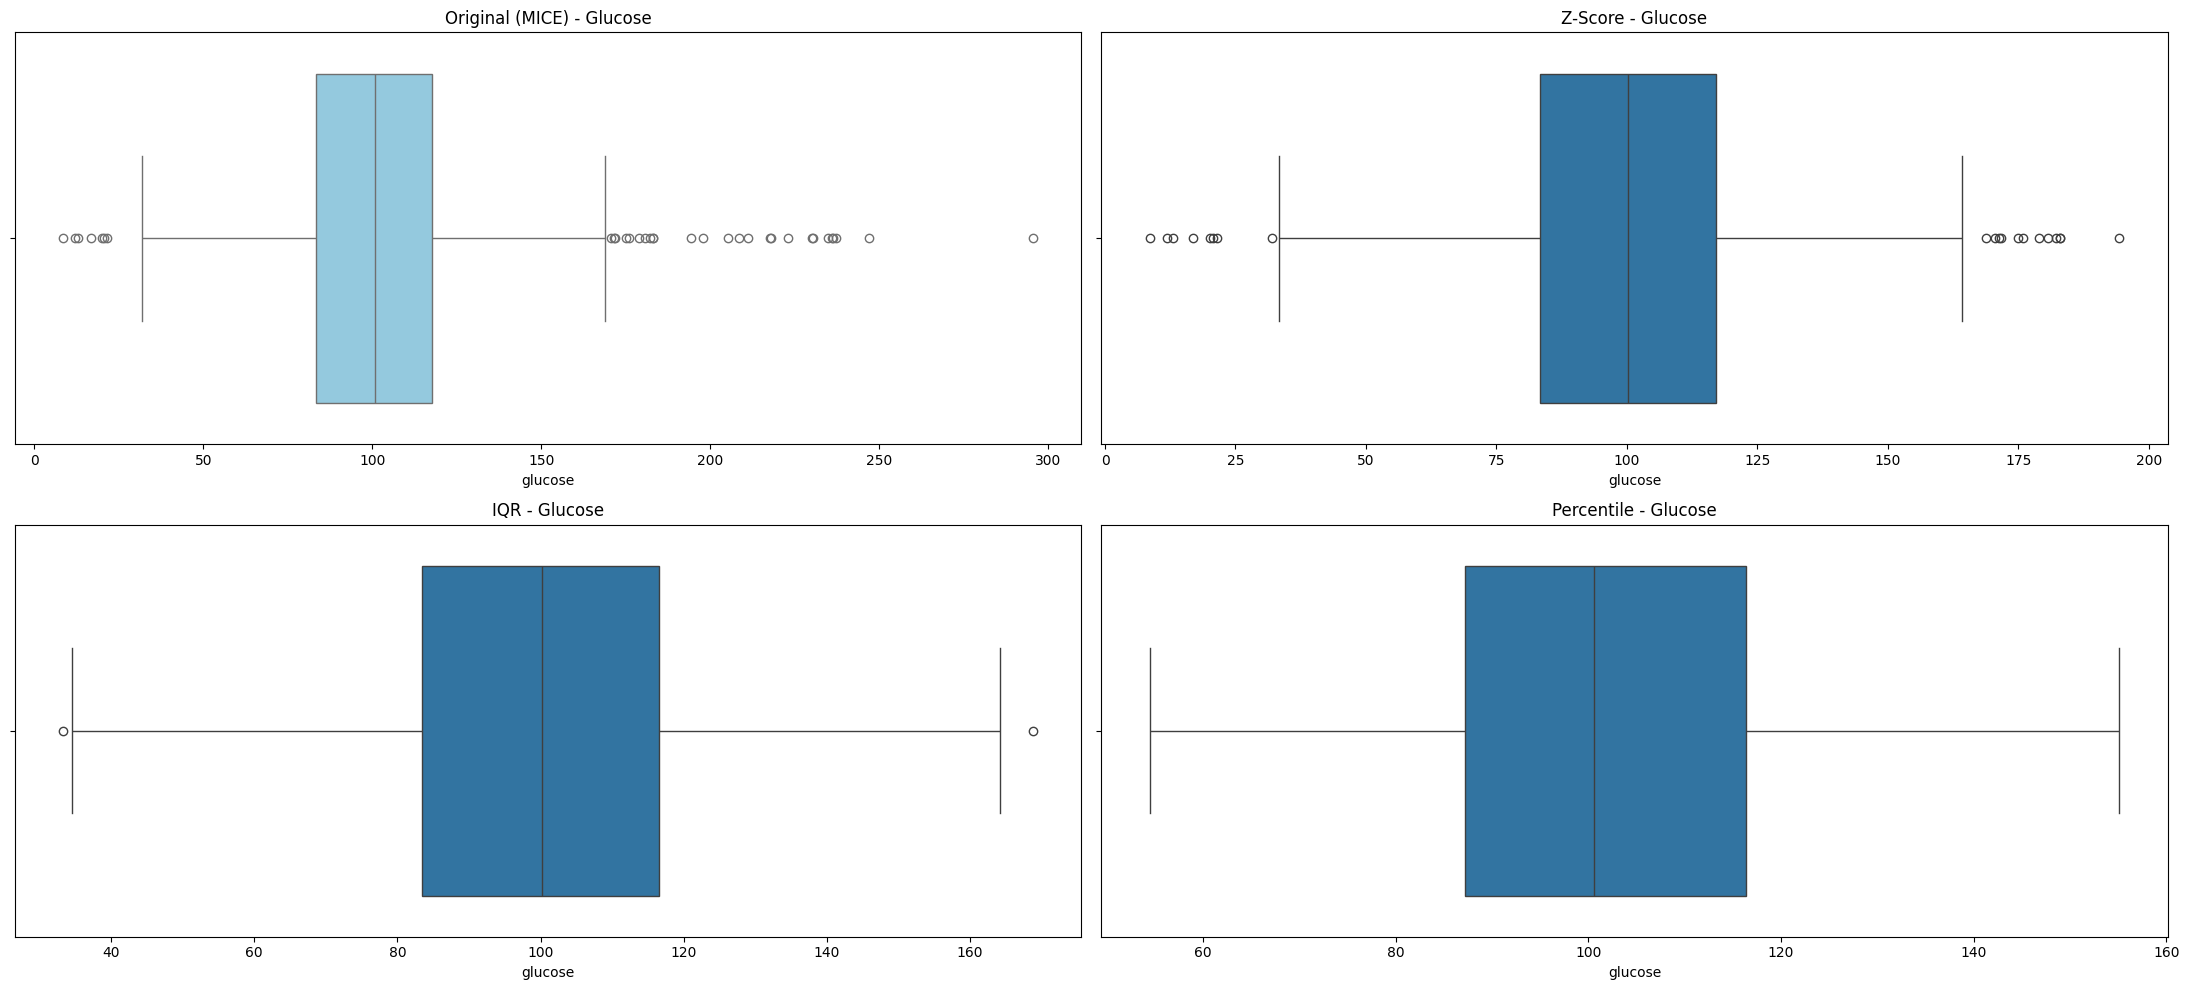

From the visualization, the Percentile method removes outliers effectively but results in higher data loss.
The IQR method provides a better balance by removing outliers while preserving most of the data.


In [151]:
# Part C
fig, ax = plt.subplots(2, 2, figsize=(22, 10))

ax = ax.ravel()

sns.boxplot(x=df_mice['glucose'], ax=ax[0], color='skyblue', orient='h')
sns.boxplot(x=df_z['glucose'], ax=ax[1], orient='h')
sns.boxplot(x=df_iqr['glucose'], ax=ax[2], orient='h')
sns.boxplot(x=df_perc['glucose'], ax=ax[3], orient='h')

ax[0].set_title("Original (MICE) - Glucose")
ax[1].set_title("Z-Score - Glucose")
ax[2].set_title("IQR - Glucose")
ax[3].set_title("Percentile - Glucose")

plt.tight_layout()
plt.show()

print("From the visualization, the Percentile method removes outliers effectively but results in higher data loss.")
print("The IQR method provides a better balance by removing outliers while preserving most of the data.")

In [152]:
print("1. Most Effective Imputation Strategy:")
print("KNN and MICE were the most effective imputation techniques because they consider relationships between variables. This helps in preserving the natural distribution and variability of the dataset compared to simple methods like mean or median.\n")

print("2. Best Outlier Handling Method:")
print("The IQR method performed best overall. Although the Percentile method removed more outliers, it caused higher data loss. IQR provided a better balance by removing extreme values while keeping most of the data intact.\n")

print("3. Dataset Usability Improvement:")
print("Data cleaning improved dataset usability by removing missing values and handling outliers effectively. This resulted in a more reliable and consistent dataset, which is suitable for further analysis and machine learning tasks.\n")

print("4. Overall Conclusion:")
print("By applying advanced imputation methods and robust outlier detection techniques, the dataset quality was significantly improved. The final cleaned dataset is more accurate, stable, and ready for predictive modeling.")

1. Most Effective Imputation Strategy:
KNN and MICE were the most effective imputation techniques because they consider relationships between variables. This helps in preserving the natural distribution and variability of the dataset compared to simple methods like mean or median.

2. Best Outlier Handling Method:
The IQR method performed best overall. Although the Percentile method removed more outliers, it caused higher data loss. IQR provided a better balance by removing extreme values while keeping most of the data intact.

3. Dataset Usability Improvement:
Data cleaning improved dataset usability by removing missing values and handling outliers effectively. This resulted in a more reliable and consistent dataset, which is suitable for further analysis and machine learning tasks.

4. Overall Conclusion:
By applying advanced imputation methods and robust outlier detection techniques, the dataset quality was significantly improved. The final cleaned dataset is more accurate, stable, 

In [154]:
print("Final Cleaned Dataset Overview")

print("\nDataset Shape:")
print("Final Shape:", df_iqr.shape)

print("\nChecking Missing Values:")
print(df_iqr.isnull().sum())

print("\nPreview of Final Dataset:")
print(df_iqr.head())

df_iqr.to_csv("final_clean_patient_dataset.csv", index=False)

Final Cleaned Dataset Overview

Dataset Shape:
Final Shape: (904, 9)

Checking Missing Values:
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
patient_id        0
dtype: int64

Preview of Final Dataset:
    age  gender region    bmi  blood_pressure  cholesterol  glucose  \
0  56.0    Male   East  18.91          128.03       173.67   141.76   
1  69.0    Male  North  22.59          131.39       184.30   109.79   
2  46.0  Female   East  18.01          140.42       208.70   126.89   
3  32.0    Male  North  24.52          105.08       166.24   100.64   
4  60.0    Male   East  26.95          127.89       133.23    98.02   

   disease_risk patient_id  
0             1     P00001  
1             0     P00002  
2             1     P00003  
3             0     P00004  
4             0     P00005  
